# Load data

In [ ]:
import pandas as pd
from IPython.core.prefilter import AutocallChecker
from pyasn1_modules.rfc7633 import Features

path = 'Data/'
df = pd.read_csv(path + 'loans_modified.csv')

# Dataset overview

In [ ]:
df.info()

- `loan_id` – Loan ID
- `gender` – Gender (Male / Female)
- `married` – Marital status (Yes / No)
- `dependents` – Number of dependents
- `education` – Education level (Graduate / Not Graduate)
- `self_employed` – Self-employment status (Yes / No)
- `applicant_income` – Applicant income
- `coapplicant_income` – Co-applicant income
- `loan_amount` – Loan amount in thousands
- `loan_amount_term` – Loan term in months
- `credit_history` – Credit history meets guidelines → Has the applicant repaid previous loans? (1 / 0)
- `property_area` – Property location (Urban / Semi Urban / Rural)
- `loan_status` – Approval status, target variable (1 / 0)

# Exploratory Data Analysis - EDA
## Pairplot

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(
    df[[
    'applicant_income',
    'coapplicant_income',
    'loan_amount',
    'loan_amount_term',
    'dependents',
    'loan_status'
    ]],
    hue='loan_status',
    diag_kind='hist',
    height=1.4,           # Höhe jedes Subplots
    aspect=1.2,           # Breite = height * aspect
    plot_kws={'s': 10}    # Punktgröße
)
plt.show()

**Column selection**

- `loan_id` → ID column, no predictive value
- `gender`, `married`, `education`, `self_employed`, `credit_history`, `property_area_*` → all binary (0/1) — scatterplots show only 4 points, completely uninformative
- `loan_status` → use as `hue`, not as axis

----------------------------

**Interpretation**

- `applicant_income`: right-skewed distribution (min: 150; max: 81,000; median: 3,762); some outliers (see boxplots)
- `coapplicant income`: analogues
- `loan_amount` & `applicant_income`: positive linear relationship (see linear regression below)

## Boxplots
### applicant_income & coapplicant_income

In [ ]:
plt.figure(figsize=(4, 3))
sns.boxplot(x='loan_status', y='applicant_income', data=df)
plt.title("Applicant Income vs Loan Status")
plt.show()

In [ ]:
plt.figure(figsize=(4, 3))
sns.boxplot(x='loan_status', y='coapplicant_income', data=df)
plt.title("CoApplicant Income vs Loan Status")
plt.show()

### loan_amount & loan_amount_term

In [ ]:
plt.figure(figsize=(4, 3))
sns.boxplot(x='loan_status', y='loan_amount', data=df)
plt.title("Loan Amount vs Loan Status")
plt.show()

In [ ]:
plt.figure(figsize=(4, 3))
sns.boxplot(x='loan_status', y='loan_amount_term', data=df)
plt.title("Loan Amount Term vs Loan Status")
plt.show()

## Linear Regression: Applicant Income vs Loan Amount

In [ ]:
plt.figure(figsize=(8, 5))
sns.regplot(
    x='applicant_income',
    y='loan_amount',
    data=df,
    scatter_kws={'alpha': 0.4}, # Einstellung für Punkte
    line_kws={'color': 'red'},   # Linienfarbe
    ci=None # CI rausnehmen
)
plt.title("Linear Regression: Applicant Income vs Loan Amount")
plt.show()

In [ ]:
from scipy import stats

clean = df[['applicant_income', 'loan_amount']].dropna()

slope, intercept, r_value, p_value, std_err = stats.linregress(
    clean['applicant_income'],
    clean['loan_amount']
)

print(f"R²: {r_value**2:.3f}")
print(f"p-value: {p_value:.4f}")
print(f"Slope: {slope:.4f}")

**Interpretation**

- The relationship is statistically significant (p = 0.000) but moderate (R² = 0.29).
- `applicant_income` explains only 29% of the variance in `loan_amount`

# Data Cleaning
## Remove Duplicates

In [ ]:
df.duplicated().sum()

In [ ]:
# Overview of Duplicates
#df[df.duplicated(keep=False)].sort_values(by=df.columns.tolist())

In [ ]:
# Remove all 25 Duplicates
df = df.drop_duplicates()

## Fixing Data Types
### Overview of Problematic Columns

In [ ]:
df.info()

In [ ]:
df.head(10).T

**Problematic Features**

These columns require transformation for two reasons:
1. Most ML algorithms expect numeric input — text strings cannot be processed directly.
2. pandas stores text as `object` dtype, a catch-all type that is ambiguous
   and can cause unexpected behavior in pipelines (e.g. during scaling or encoding).

- `loan_id` — pure identifier → drop
- `gender` — Male/Female → 0/1
- `married` — Yes/No → 0/1
- `dependents` — 0/1/2/3+ → ordinal integer (3+ problematic)
- `education` — Graduate/Not Graduate → 0/1
- `self_employed` — Yes/No → 0/1
- `property_area` — Rural/Urban/Semiurban → One-Hot Encoding

### Object → String Conversion

In [ ]:
# Strictly speaking unnecessary for the ML pipeline: loan_id will be dropped later.
# However, converting object to string dtype is good practice It makes the column's intent explicit and avoids ambiguity.
df['loan_id'] = df['loan_id'].astype('string')

In [ ]:
# Which columns still have object dtype?
print(df.select_dtypes(include='object').info())

### Column 'Dependents'

In [ ]:
print(df['dependents'].unique())

- es gibt also 4 Gruppen
- diese sind geordnet (2 > 1 usw.), d.h. ordinal

- 4 distinct groups
- values are ordered (2 > 1 etc.), i.e. ordinal

**Options**
- (1) One-hot encoding → results in multiple columns and loses ordinality
- (2) Convert to integer, replace 3+ with 3 → loses "3 or more" distinction,
  drops all NaNs (pandas cannot store NaN in integer columns), ordinality PRESERVED
- (3) Convert to float, replace 3+ with 3 → loses "3 or more" distinction,
  NaNs PRESERVED, ordinality PRESERVED => **My Choice**


In [ ]:
# Convert to float and replace 3+ with 3
df['dependents'] = df['dependents'].replace('3+', 3).astype(float)

### Binary columns

In [ ]:
print(df.select_dtypes(include='object').info())
print()
print("Column married: ", df['married'].unique())
print("Column education: ", df['education'].unique())
print("Column self_employed: ", df['self_employed'].unique())
print("Column gender: ", df['gender'].unique())
#print("Column loan_status: ", df['loan_status'].unique())

In [ ]:
# Binary Encoding
df = (df
  # assign = mutate
  # map um Werte zu ersetzen
  .assign(married       = lambda x: x['married'].map({'Yes': 1, 'No': 0}))
  .assign(education     = lambda x: x['education'].map({'Graduate': 1, 'Not Graduate': 0}))
  .assign(self_employed = lambda x: x['self_employed'].map({'Yes': 1, 'No': 0}))
  .assign(gender        = lambda x: x['gender'].map({'Male': 1, 'Female': 0}))
  #.assign(loan_status   = lambda x: x['loan_status'].map({1: 'approved', 0: 'rejected'}))
)

In [ ]:
# Binary encoding was successful? => yes!
print(df.select_dtypes(include='object').info())
print()
print("Column married: ", df['married'].unique())
print("Column education: ", df['education'].unique())
print("Column self_employed: ", df['self_employed'].unique())
print("Column gender: ", df['gender'].unique())
#print("Column loan_status: ", df['loan_status'].unique())

### 'property_area': Imputation & One-Hot encoding

In [ ]:
print("property_area: ", df['property_area'].unique())

**Ordinal or Nominal?**
- (a) Ordinal: Rural < Semi Urban < Urban
- (b) Nominal: the three areas are simply different categories without a clear ranking
- When in doubt whether it is (a) or (b), treat as nominal → One-Hot Encoding

**Why impute before One-Hot Encoding?**

`get_dummies` silently handles NaN — no warning, no exception:
- A row with `property_area = NaN` receives 0 in all one-hot columns
- With `drop_first=True`, 0/0 corresponds to the reference category Rural
- → NaN is implicitly treated as Rural, even though the value is missing

**Solution: Impute before get_dummies**
- Mode imputation: NaN → most frequent value (Urban)
- Alternative: introduce an "Unknown" category — useful if missingness itself is informative
- With few NaNs (as here), mode imputation is the more pragmatic choice

**Code explanation**
- (1) Argument `drop_first=True`: with columns (1) `property_area_Semiurban` and (2) `property_area_Urban`,
  category Rural can be inferred — it remains implicit (if both are 0, the area is Rural).
  Note: categories are sorted alphabetically; the first one is dropped.
- (2) Argument `dtype=int`: by default, `get_dummies` returns boolean dtype (True/False),
  which can cause issues with some ML models.

In [ ]:
df['property_area'] = df['property_area'].fillna(df['property_area'].mode()[0])
df = pd.get_dummies(df, columns=['property_area'], drop_first=True, dtype=int)

In [ ]:
# All object - dtypes fixed? => yes!
df.info()

## Treating Missing Data

In [ ]:
# Overview missing data
missing = pd.DataFrame({
    'absolut': df.isnull().sum(),
    'prozent': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('prozent', ascending=False)

print(missing)

**Missing Data Strategy**

`loan_id`
- Pure identifier, no predictive information
- → my choice: drop column

`loan_status`
- Target variable - rows without it are useless for the model
- → my choice: drop rows with NaN

`gender`, `married`, `education`, `self_employed`, `dependents`
- Categorical columns
- Without domain knowledge, mode imputation is the conservative default strategy.
  It introduces the most frequently observed value and is well-established in the literature.
  Ideally, alternatives would be discussed with a domain expert.
- → my choice: mode

`applicant_income`, `coapplicant_income`, `loan_amount`, `loan_amount_term`
- Numerical columns
- As shown in the boxplots, some outliers are present
- Without domain knowledge, median imputation is the conservative default strategy
  (robust to outliers and well-established in the literature).
- → my choice: median

`credit_history` → special case
- Strongest predictor in the model (see correlation matrix and Chi-Square Test; both conducted below)
- Mode would be `1` → would introduce bias
- → my choice: drop rows with NaN

In [ ]:
df = (df
    .drop(columns='loan_id')
    .dropna(subset=['loan_status', 'credit_history'])
    .assign(
        gender             = lambda x: x['gender'].fillna(x['gender'].mode()[0]),
        married            = lambda x: x['married'].fillna(x['married'].mode()[0]),
        education          = lambda x: x['education'].fillna(x['education'].mode()[0]),
        self_employed      = lambda x: x['self_employed'].fillna(x['self_employed'].mode()[0]),
        dependents         = lambda x: x['dependents'].fillna(x['dependents'].mode()[0]),
        applicant_income   = lambda x: x['applicant_income'].fillna(x['applicant_income'].median()),
        coapplicant_income = lambda x: x['coapplicant_income'].fillna(x['coapplicant_income'].median()),
        loan_amount        = lambda x: x['loan_amount'].fillna(x['loan_amount'].median()),
        loan_amount_term   = lambda x: x['loan_amount_term'].fillna(x['loan_amount_term'].median()),
    )
)

In [ ]:
# Missing data removed/imputed? => yes!
missing = pd.DataFrame({
    'absolut': df.isnull().sum(),
    'prozent': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('prozent', ascending=False)

print(missing)

## Handling Outliers

**Columns with outliers (see boxplots)**
- `applicant_income`
- `coapplicant_income`
- `loan_amount`
- `loan_amount_term`

**Are outliers true errors or genuine extreme values?**
- Cannot be determined without domain knowledge.

Option A: Dropping
- Treat outliers as true errors
- → drop via IQR method

Option B: Log Transformation
- Applied when the distribution is strongly right-skewed
- Compresses extreme values without removing them
- Potentially useful for `applicant_income` and `loan_amount`
- Disadvantage: interpretation of model coefficients becomes more difficult

Option C: Capping
- Set values above the 99th percentile to the 99th percentile
- Set values below the 1st percentile to the 1st percentile
- → **my choice: no data loss**

In [ ]:
# How many values are effected by Capping?
for col in ['applicant_income', 'coapplicant_income', 'loan_amount', 'loan_amount_term']:
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)
    n_lower = (df[col] < lower).sum()
    n_upper = (df[col] > upper).sum()
    print(f"{col}: {n_lower} unter lower, {n_upper} über upper")

In [ ]:
# Capping
for col in ['applicant_income', 'coapplicant_income', 'loan_amount', 'loan_amount_term']:
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)
    df[col] = df[col].clip(lower=lower, upper=upper)

# Feature Engineering - Creating New Features

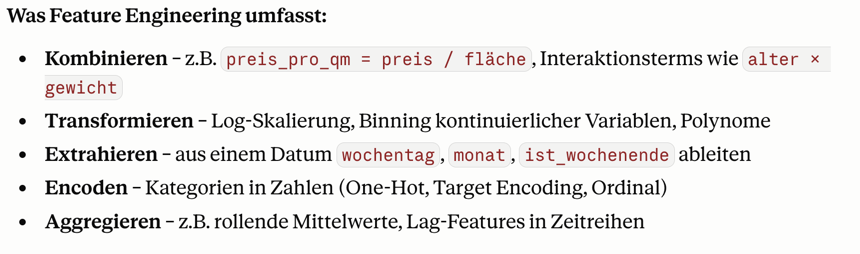

**Why Feature Engineering at this point in the workflow?**
- Data cleaning is complete at this stage, but scaling has not yet been applied.
  This is the right moment: scaling before feature engineering would distort the
  source columns — adding or dividing scaled values produces uninterpretable new features.
- Note: the new features will need to be scaled afterwards as well.

In [ ]:
df.info()

In [ ]:
df = (
    df
    # ...fe steht für feature engineering
    .assign(combined_income_fe = lambda x: x["applicant_income"] + x["coapplicant_income"])
    .assign(loan_to_income_ratio_fe = lambda x: x["loan_amount"] / x["combined_income_fe"])
)

In [ ]:
df.head().T

## Properties of New Features

In [ ]:
plt.figure(figsize=(6, 4))
sns.boxplot(x='loan_status', y='combined_income_fe', data=df)
plt.title("combined_income_fe vs loan_status")
plt.show()

In [ ]:
plt.figure(figsize=(6, 4))
sns.boxplot(x='loan_status', y='loan_to_income_ratio_fe', data=df)
plt.title("loan_to_income_ratio vs loan_status")
plt.show()

- `loan_to_income_ratio` has outliers
- `combined_income` has outliers

## Handling Outliers: Capping Again

**Background**
- Engineered features can introduce new outliers, even if the source features were already capped
- As shown above, this is exactly the case here — this is not surprising given that
  capping was applied conservatively at the 1st and 99th percentiles, leaving room
  for extreme combinations in derived features
- → apply capping to the new features as well

In [ ]:
# Capping auf P1 und P99
df = (
    df
    .assign(combined_income_fe = lambda x: x["combined_income_fe"].clip(
        lower=x["combined_income_fe"].quantile(0.01),
        upper=x["combined_income_fe"].quantile(0.99)
    ))
    .assign(loan_to_income_ratio_fe = lambda x: x["loan_to_income_ratio_fe"].clip(
        lower=x["loan_to_income_ratio_fe"].quantile(0.01),
        upper=x["loan_to_income_ratio_fe"].quantile(0.99)
    ))
)

# Extended EDA

Why at this point in the workflow?
- **Chi-square test**: the one-hot encoded features `property_area_Semiurban` and
  `property_area_Urban` are now available and can be included
- **T-test**: the engineered features `combined_income_fe` and `loan_to_income_ratio_fe`
  are now available and can be included

## Chi-Square-Test
### Background

**The chi-square test is a statistical procedure for testing whether a significant
association exists between CATEGORICAL variables.**
Observed frequencies in each category are compared against the expected frequencies
that would arise under the assumption of no relationship (independence) between the variables.

→ The question asked here: **"Is feature X associated with `loan_status`?"**

### Definition of Categorical Features

In [ ]:
# Overview of feaures
df.head().T

In [ ]:
# => List of categorical Features
cat_features = [
    'loan_status',
    'gender',
    'married',
    'dependents',
    'education',
    'self_employed',
    'credit_history',
    'property_area_Semiurban',
    'property_area_Urban'
]

### Test

In [ ]:
from scipy.stats import chi2_contingency
import numpy as np

# (1) Zu untersuchende kategoriale Features definieren => hier loan_status raus nehmen, da Zusammenhang hierauf getestet wird
cat_features_ = [
    #'loan_status',
    'gender',
    'married',
    'dependents',
    'education',
    'self_employed',
    'credit_history',
    'property_area_Semiurban',
    'property_area_Urban'
]

# (2) Chi-Square Test + Cramér's V für jedes Feature berechnen
results = []
for col in cat_features_:
    # Kreuztabelle: Feature (Zeilen) vs. loan_status (Spalten)
    ct = pd.crosstab(df[col], df['loan_status'])
    # Chi-Quadrat-Test: gibt Teststatistik, p-Wert, Freiheitsgrade und Erwartungswerte zurück
    chi2, p, dof, _ = chi2_contingency(ct)
    # Gesamtanzahl Beobachtungen (Summe aller Zellen der Kreuztabelle) => wird für Cramers V Berchnung benötigt
    n = ct.sum().sum()
    # Cramér's V: Effektgröße für kategoriale Zusammenhänge (0 = kein, 1 = perfekter Zusammenhang)
    # min(ct.shape) - 1 = kleinere Dimension der Tabelle - 1 (Korrektur für Tabellenformat)
    cramers_v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))
    # Ergebnisse in Liste speichern
    results.append({'feature': col, 'chi2': chi2, 'p-value': p, "cramér's v": cramers_v})

# (3) Ergebnisse als DataFrame aufbereiten, nach p-Wert sortieren und formatieren
df_chi2 = (pd.DataFrame(results)
    .sort_values('p-value')
    .style.format({'chi2': '{:.3f}', 'p-value': '{:.4f}', "cramér's v": '{:.3f}'})
)

df_chi2

- `credit_history` - strongest association with `loan_status` (Cramér's V = 0.494, strong),
  highly significant (p ≈ 0). Most important categorical feature for loan approval.
- `property_area_Semiurban` - significant association (p = 0.014),
  but moderate effect (Cramér's V = 0.111).
- `married` - marginally non-significant (p = 0.070), weak effect (Cramér's V = 0.082).
  Borderline case - retain in model but interpret with caution.
- `gender`, `education`, `self_employed`, `dependents`, `property_area_Urban` -
  no significant association (p > 0.05) and weak effect sizes (Cramér's V < 0.1).
  Despite domain plausibility, no measurable statistical association with `loan_status` -
  these features are unlikely to have predictive influence in the model.

## T-Test

In [ ]:
num_features = df[['combined_income_fe', 'loan_to_income_ratio_fe', 'loan_amount', 'loan_amount_term', 'loan_status']]
num_features['loan_status'] = num_features['loan_status'].map({1: 'approved', 0: 'rejected'})

num_features.boxplot(
    by='loan_status',
    figsize=(14, 5),
    layout=(1, 4),
    sharey=False # individuelle y-Achsen
)
plt.suptitle('Numerische Features vs. loan_status')
plt.tight_layout()
plt.show()

**Visual Inspection**

At first glance, the boxplots do not suggest any obvious difference in the
distribution of numerical features between the approved and rejected groups -
consistent with the t-test results below.

In [ ]:
from scipy.stats import ttest_ind

num_features = ['combined_income_fe', 'loan_to_income_ratio_fe',
                'loan_amount', 'loan_amount_term']

results = []
for col in num_features:
    group0 = df[df['loan_status'] == 0][col]
    group1 = df[df['loan_status'] == 1][col]
    _, p = ttest_ind(group0, group1)
    results.append({'numeric feature': col, 'p-value': p})

df_ttest = (pd.DataFrame(results)
    .sort_values('p-value')
    .style.format({'p-value': '{:.4f}'})
)

df_ttest

**Interpretation:**
- None of the numerical features show a statistically significant difference between approved and rejected
- `loan_to_income_ratio_fe` is at least marginally significant (p < 0.10)
- Confirms the finding from the correlation matrix: numerical features correlate poorly with `loan_status`

# Preprocessing
## Scaling

- Scaling is irrelevant for tree-based models (no benefit, but no harm either); required for models such as logistic regression
- **(I) StandardScaler**
    - Applies Z-score standardisation: (x - mean) / std
    - Strictly speaking assumes normally distributed input
    - Result: mean = 0, standard deviation = 1
    - `applicant_income` is right-skewed → normality assumption violated
- **Alternatives to StandardScaler**
    - **(II) MinMaxScaler**
        - Formula: (x - min) / (max - min)
        - Result: values scaled to [0, 1]
        - Does not assume normality, but sensitive to outliers
    - **(III) RobustScaler**
        - Robust to outliers
        - Formula: (x - median) / IQR
- In practice, StandardScaler is still commonly used for logistic regression
    - Logistic regression is robust enough to mild violations of normality
    - → **My choice: StandardScaler as a pragmatic compromise**

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
numeric_cols = [
    'applicant_income',
    'coapplicant_income',
    'loan_amount',
    'loan_amount_term',
    'combined_income_fe',
    'loan_to_income_ratio_fe'
]

df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

## Multicolinearity

**Definition:** Multicollinearity refers to the phenomenon where two or more independent variables (features) are strongly linearly correlated with each other.
- The correlation matrix only reveals bivariate multicollinearity; multivariate collinearity can be assessed via VIF (Variance Inflation Factor).

- For tree-based models, multicollinearity has no effect on model performance.
- However, it does affect models such as logistic regression.

In [ ]:
# Spaltenreihenfolge definieren
cols = ['loan_status', 'credit_history', 'gender', 'married', 'dependents',
        'education', 'self_employed', 'loan_amount', 'loan_amount_term',
        'property_area_Semiurban', 'property_area_Urban',
        'applicant_income', 'coapplicant_income',
        'combined_income_fe', 'loan_to_income_ratio_fe']

# Berechne Korrelationsmatrix (bilde alle paarweisen Pearson-Korrelationen)
corr_matrix = df[cols].corr(numeric_only=True)
#print(corr_matrix)
#print()

# Erstelle Heatmap für Korrelationsmatrix #
plt.figure(figsize=(10, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title("Pearson-Korrelation Heatmap")
plt.show()

**Association between target variable `loan_status` and features**
- `credit_history` is by far the strongest predictor (r = 0.50) and dominates the model
- All other features correlate weakly with `loan_status` (all < |0.12|)
    - → no meaningful interpretation justified here

**(I) Multicollinearity among original features**
- Only low correlations, well below the rule-of-thumb threshold of r = 0.7
- → no feature reduction necessary

**(II) Multicollinearity among engineered features**
- Combined:
    - (a) `applicant_income` + `coapplicant_income` → `combined_income_fe`
    - (b) `loan_amount` / `combined_income_fe` → `loan_to_income_ratio_fe`
- Observed:
    - (1) `combined_income_fe` ↔ `loan_amount`: r = 0.67 => moderate correlation
    - (2) `loan_to_income_ratio_fe` ↔ `combined_income_fe`: r = -0.40 => moderate correlation
    - (3) `loan_to_income_ratio_fe` ↔ `applicant_income`: r = -0.33 => moderate correlation;
      dropped after removing `applicant_income` (see below)
        - => (1)–(3): moderate correlation between an engineered feature and its components is expected, can not be avoided and can be tolerated
    - (4) `applicant_income` ↔ `combined_income_fe`: r = 0.91
        - => suggests that `coapplicant_income` is zero or very small for many observations
        - `combined_income_fe` is almost entirely driven by `applicant_income`

- Decision:
    - **Option A:** drop `applicant_income` + `coapplicant_income`, retain `combined_income_fe`
    - **Option B:** drop `combined_income_fe`, retain `applicant_income` + `coapplicant_income`
    - → **Option A chosen because:**
        - (1) `combined_income_fe` is more informative (total household income)
        - (2) Removing redundant features can yield a more robust model by reducing
          multicollinearity, overfitting, and noise

In [ ]:
df = df.drop(columns=['applicant_income', 'coapplicant_income'])

## Train Test Split

In [ ]:
# Imbalanced dataset? Check class distribution before splitting. => result: imbalanced!
class_distribution = pd.DataFrame({
    'absolut': df['loan_status'].value_counts(),
    'percentage': (df['loan_status'].value_counts() / len(df) * 100).round(2)
})

class_distribution

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop(columns='loan_status')
y = df['loan_status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # ensures class distribution is preserved in both train and test set
)

# Machine Learning
## Evaluation Metrics - Pros and Cons

**Assumption due to missing description**
- 1 in `loan_status` = loan approved, 0 = loan rejected

**General Terminology**
| Term | predicted | true | Logic |
|---|---|---|---|
| **TP** (True Positive)  | 1 | 1 | predicted positive → correct  |
| **TN** (True Negative)  | 0 | 0 | predicted negative → correct  |
| **FP** (False Positive) | 1 | 0 | predicted positive → wrong    |
| **FN** (False Negative) | 0 | 1 | predicted negative → wrong    |

**Evaluation Metrics**
- (1) Accuracy
    - A model that always predicts 1 achieves 71.4% accuracy in this data set (see class distribution)
    - → unsuitable for imbalanced datasets

- **(2) Recall for class 0**
    - Recall(0) = TN / (TN + FP)
    - → **Of all truly bad borrowers (true=0): how many did the model correctly identify as rejected?**
    - FP here: true=0, predicted=1 → bad borrower incorrectly approved

- (3) Precision for class 0
    - Precision(0) = TN / (TN + FN)
    - → Of all predicted rejections: how many were truly bad borrowers?
    - FN here: true=1, predicted=0 → good borrower incorrectly rejected
    - Low Precision(0): many good borrowers rejected → lost business, but no direct loss for the bank

- **(4) Precision for class 1**
    - Precision(1) = TP / (TP + FP)
    - → **Of all predicted approvals: how many were truly reliable borrowers?**
    - FP here: true=0, predicted=1 → bad borrower incorrectly approved → direct financial loss for the bank

**Options**
- (a) Optimise Recall(0)
    - Model learns: "when in doubt, predict rejected" → minimises FP
    - Extreme case: model predicts everything as 0 → Recall(0) = 1.0, but Precision(0) collapses
    - → all customers rejected, bank makes no business

- (b) Optimise Precision(1)
    - Model learns: "only approve when very confident" → minimises FP
    - Extreme case: model predicts almost everything as 0 → same problem

- **(c) F1-Score(0)**
    - F1(0) = 2 × [Precision(0) × Recall(0)] / [Precision(0) + Recall(0)]
    - **Maximised when both Precision(0) and Recall(0) are simultaneously high**
    - Balances:
        - Precision(0): how many of the rejected were truly bad borrowers?
        - Recall(0): how many bad borrowers were correctly identified?
    - → **F1(0) is my choice**

## Logistic Regression
### Initialise, Train, Predict

In [ ]:
from sklearn.linear_model import LogisticRegression

# Initialise
log_reg = LogisticRegression(random_state=42)

# Train
log_reg.fit(X_train, y_train)

# Predict
y_pred = log_reg.predict(X_test)

### Evaluation

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

# For comparison of models
report_log_reg_default = classification_report(y_test, y_pred,          output_dict=True)

###  Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# (1) Parameter grid: only valid solver-penalty combinations
## Not all solver-penalty combinations are valid in sklearn => two separate dictionaries
param_grid = [
    {
        'solver': ['liblinear'],      # liblinear optimises one coefficient at a time, holding all others fixed
        'penalty': ['l1', 'l2'],      # L1: sets unimportant coefficients to exactly 0 (sparse solution)
        'C': [0.01, 0.1, 1, 10, 100], # higher C = less regularisation; lower C = coefficients shrunk toward 0
        'max_iter': [100, 500]
    },
    {
        'solver': ['lbfgs'],     # lbfgs optimises all coefficients simultaneously
        'penalty': ['l2'],       # L2: shrinks all coefficients evenly toward 0 => reduces overfitting on individual features
        'C': [0.01, 0.1, 1, 10, 100],
        'max_iter': [100, 500]
    }
]

# (2) Evaluation metric: inject F1-score via scorer
from sklearn.metrics import make_scorer, f1_score

# Scoring metric: F1(0) — balances Precision(0) and Recall(0) for class 0 (rejected)
f1_class0 = make_scorer(f1_score, pos_label=0)

# (3) GridSearchCV: tests all combinations via 5-fold cross-validation
grid_search = GridSearchCV(
    estimator=LogisticRegression(),
    param_grid=param_grid,
    cv=5,
    scoring=f1_class0,
    n_jobs=-1
)

# (4) Fit on training data only — no data leakage
grid_search.fit(X_train, y_train)

# (5a) Best parameter combination from Grid Search
print(grid_search.best_params_)
# (5b) Mean F1(0) across 5-fold CV on X_train
print(grid_search.best_score_)

# (6) Best model for final predictions on X_test
best_model = grid_search.best_estimator_

### Evaluation of tuned model

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

# Train model with best parameters
log_reg_tuned = grid_search.best_estimator_
log_reg_tuned.fit(X_train, y_train)

# Predict
y_pred_tuned = log_reg_tuned.predict(X_test)

# Evaluation
print(classification_report(y_test, y_pred_tuned))
print("Accuracy:", accuracy_score(y_test, y_pred_tuned))

# Report for comparison of models
report_log_reg_tuned   = classification_report(y_test, y_pred_tuned,    output_dict=True)

## Random Forest
### Initialise, Train, Predict

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# (1) Initialise
rf = RandomForestClassifier(random_state=42)

# (2) Train
rf.fit(X_train, y_train)

# (3) Predict
y_pred_rf = rf.predict(X_test)

### Evaluation

In [ ]:
print(classification_report(y_test, y_pred_rf))

# Report for comparison of models
report_rf_default      = classification_report(y_test, y_pred_rf,       output_dict=True)

### Hyperparameter Tuning

In [ ]:
param_grid_rf = {
    'n_estimators': [100, 200, 300],  # number of trees in the forest
    'max_depth': [None, 5, 10],       # maximum depth of each tree — None = unlimited
    'min_samples_split': [2, 5, 10],  # minimum number of samples required to split a node (default = 2)
    'min_samples_leaf': [1, 2, 4]     # minimum number of samples required in a leaf node (default = 1)
}

grid_search_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid_rf,
    cv=5,
    scoring=f1_class0,
    n_jobs=-1
)

grid_search_rf.fit(X_train, y_train)

print(grid_search_rf.best_params_)
print(grid_search_rf.best_score_)

### Evaluation of tuned model

In [ ]:
# Extract best model (optimal hyperparameters from Grid Search)
rf_tuned = grid_search_rf.best_estimator_

# Train & Predict
rf_tuned.fit(X_train, y_train)
y_pred_rf_tuned = rf_tuned.predict(X_test)

print(classification_report(y_test, y_pred_rf_tuned))

# For comparison of models
report_rf_tuned = classification_report(y_test, y_pred_rf_tuned, output_dict=True)

## Model selection
### Logistic Regression vs. Random Forest
#### ... with respect to Evaluation Metric (F1-Score)

In [ ]:
# Merge class 0 metrics from reports (= dictionaries) into a DataFrame
df_metrics = pd.DataFrame({
    'Log. Reg. (default)': report_log_reg_default['0.0'],
    'Log. Reg. (tuned)':   report_log_reg_tuned['0.0'],
    'RF (default)':        report_rf_default['0.0'],
    'RF (tuned)':          report_rf_tuned['0.0']
}).loc[['f1-score', 'recall', 'precision']]

# Pivot longer (melt)
df_long = (df_metrics
    .reset_index()
    .rename(columns={'index': 'metric'})
    .melt(id_vars='metric', var_name='model', value_name='score')
)

# Plot
import seaborn as sns

palette = {
    'Log. Reg. (default)': '#444441',
    'Log. Reg. (tuned)':   '#B4B2A9',
    'RF (default)':        '#1D9E75',
    'RF (tuned)':          '#9FE1CB'
}

sns.barplot(
    data=df_long,
    x='metric',
    y='score',
    hue='model',
    palette=palette
)
plt.ylim(0, 1)
plt.title('Model Comparison — Metrics for Class 0 (Loan Rejected)')
plt.xlabel('Metrik')
plt.ylabel('Score')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Display values as percentages with one decimal place
df_metrics.T.style.format("{:.1%}")

**Model Comparison - Interpretation**

**F1-Score (class 0) - primary metric:**
- RF (default + tuned) = 59.6% => marginally best
- Log. Reg. (default + tuned) = 59.1% => just behind
- Difference: 0.5 percentage points => practically meaningless

**Effect of tuning:**
- No effect - default and tuned are identical for both models
- Possible reasons:
    - Dataset too small (~500 observations) for stable tuning
    - Default parameters already close to optimal for this dataset
    - Class imbalance (71% approved) makes learning the minority class harder

**Recall / Precision trade-off:**
- Log. Reg.: high Precision (81.2%), weak Recall (46.4%)
    - => identifies only 46% of truly bad borrowers
- RF: lower Precision (73.7%), better Recall (50.0%)
    - => identifies more bad borrowers, but also rejects more good customers

**Conclusion:**
- No model is clearly superior, differences are marginal
- For the bank's business objective (minimise credit default risk), RF is the
  better choice due to higher Recall(0): of 100 bad borrowers, RF identifies
  50 vs. 46 for logistic regression

#### ... with respect to Generalisation

In [ ]:
from sklearn.metrics import f1_score

y_pred_rf_train      = rf.predict(X_train)
y_pred_rf_test       = rf.predict(X_test)

y_pred_log_reg_train = log_reg.predict(X_train)
y_pred_log_reg_test  = log_reg.predict(X_test)

print("RF        — Train F1(0):", round(f1_score(y_train, y_pred_rf_train,      pos_label=0), 3))
print("RF        — Test  F1(0):", round(f1_score(y_test,  y_pred_rf_test,       pos_label=0), 3))
print()
print("Log. Reg. — Train F1(0):", round(f1_score(y_train, y_pred_log_reg_train, pos_label=0), 3))
print("Log. Reg. — Test  F1(0):", round(f1_score(y_test,  y_pred_log_reg_test,  pos_label=0), 3))

**Generalisation:**
- RF: Train F1(0) = 100%, Test F1(0) = 59.6% → **severe overfitting!!**
- Log. Reg.: Train F1(0) = 52.8%, Test F1(0) = 59.1% => no overfitting, stable generalisation

**Despite marginally lower Test F1(0) and Recall, Logistic Regression is clearly preferable over Random Forest!**

### ROC - Curve
#### Comparison of Both Models

In [ ]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# Predicted probabilities for class 1
y_prob_log_reg = log_reg.predict_proba(X_test)[:, 1]
y_prob_rf      = rf.predict_proba(X_test)[:, 1]

# Compute ROC curves
fpr_lr, tpr_lr, thresholds_lr = roc_curve(y_test, y_prob_log_reg, pos_label=1)
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_prob_rf,      pos_label=1)

# Plot
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(fpr_lr, tpr_lr, label='Log. Reg. (default)', color='#444441')
ax.plot(fpr_rf, tpr_rf, label='RF (default)',         color='#1D9E75')
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Classifier')

ax.set_xlabel('False Positive Rate (FPR)')
ax.set_ylabel('True Positive Rate (Recall; TPR)')
ax.set_title('ROC Curve (positive class = 1)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**ROC Curve — Interpretation**
- Both models clearly outperform random chance (diagonal)
- RF appears superior to logistic regression according to ROC
    - RF lies clearly above Log. Reg. in the mid-FPR range (0.15–0.55)
    - At very low FPR (< 0.15) and high FPR (> 0.55) both models perform similarly

**However:**
- ROC/AUC does not account for generalisation ability
- RF shows severe overfitting (Train F1 = 100%) - the AUC advantage must therefore be interpreted with caution
- Logistic Regression remains the more robust model

#### Extract Optimal Threshold for Logistic Regression (maximising F1 for class 0)

In [ ]:
from sklearn.metrics import f1_score
import numpy as np

thresholds_to_test = np.arange(0.1, 0.9, 0.05)

f1_scores = []
for t in thresholds_to_test:
    y_pred_t = (y_prob_log_reg >= t).astype(int)
    f1_scores.append(f1_score(y_test, y_pred_t, pos_label=0))

optimal_threshold = thresholds_to_test[np.argmax(f1_scores)]
print(f"Optimal Threshold: {optimal_threshold:.2f}")
print(f"Best F1(0): {max(f1_scores):.3f}")

pd.DataFrame({
    'threshold': thresholds_to_test,
    'f1_score':  f1_scores
}).style.format({'threshold': '{:.2f}', 'f1_score': '{:.3f}'})

**Threshold Analysis - Logistic Regression (default)**
- Optimal threshold: 0.55 with F1(0) = 0.609
- Default threshold 0.50 nearly optimal (F1 = 0.59) - marginal difference

**Limitation:**
- Threshold optimisation was performed on the test set
- Evaluation is also performed on the test set
- A separate validation set would be methodologically cleaner (e.g. 80/10/10 split)
- With ~500 observations, a three-way split is problematic as individual sets become too small
- The threshold optimisation shown here is therefore NOT robust

### AUC

In [ ]:
# AUC - Area under the curve
from sklearn.metrics import roc_auc_score

auc_lr = roc_auc_score(y_test, y_prob_log_reg)
auc_rf = roc_auc_score(y_test, y_prob_rf)

print(f"AUC Log. Reg.: {auc_lr:.3f}")
print(f"AUC RF:        {auc_rf:.3f}")

**Interpretation AUC**
- RF outperforms Logistic Regression according to AUC: RF (0.741) > Log. Reg. (0.711)
- However: generalisation ability is not captured here either

### Final Evaluation - Logistic Regression (threshold = 0.55)
#### Evaluation Metrics Overview

In [ ]:
y_pred_log_reg_optimal = (y_prob_log_reg >= optimal_threshold).astype(int)

print(classification_report(y_test, y_pred_log_reg_optimal))

report_log_reg_optimal = classification_report(y_test, y_pred_log_reg_optimal, output_dict=True)

#### Confusion Matrix

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_rf_optimal = confusion_matrix(y_test, y_pred_log_reg_optimal)

disp_rf_optimal = ConfusionMatrixDisplay(confusion_matrix=cm_rf_optimal, display_labels=['Abgelehnt', 'Genehmigt'])
disp_rf_optimal.plot(cmap='Greens')
plt.title('Confusion Matrix: Random Forest (Threshold = 0.55)')
plt.grid(False)
plt.show()

- FN = 4 is relatively low => good for customers: very few creditworthy applicants would be incorrectly rejected if the bank were to deploy this model

#### Feature Importance

In [ ]:
feature_importance_log_reg = pd.DataFrame({
    'feature':    X_train.columns,
    'importance': np.abs(log_reg.coef_[0]),
    'odds_ratio': np.exp(log_reg.coef_[0])
}).sort_values('odds_ratio', ascending=True)

feature_importance_log_reg.plot(
    x='feature',
    y='odds_ratio',
    kind='barh',
    figsize=(8, 6),
    legend=False,
    title='Feature Importance — Logistische Regression (Odds Ratios)'
)
plt.axvline(x=1, color='gray', linestyle='--', linewidth=1)  # Referenzlinie bei OR=1
plt.xlabel('Odds Ratio')
plt.tight_layout()
plt.show()

In [ ]:
# Spaltennamen präzisieren: Betrag der Koeffizienten = Log Odds
feature_importance_log_reg = feature_importance_log_reg.rename(
    columns={'importance': 'importance (|coefficients = log odds|)'}
)

# Faktor: wie viel mal höher/niedriger ist die Genehmigungswahrscheinlichkeit?
feature_importance_log_reg['factor'] = feature_importance_log_reg['odds_ratio'].apply(
    lambda x: f"+{x:.2f}x" if x >= 1 else f"-{1/x:.2f}x"
)

In [ ]:
feature_importance_log_reg

- `credit_history` dominates with Odds Ratio = 20.6 => a good credit history increases approval probability by a factor of 20.6
    - consistent with chi-square analysis (Cramér's V = 0.49)
- All other odds ratios are very close to 1 => minimal influence on the lending decision
- Note: whether an OR is statistically significant cannot be determined without confidence intervals - with a small dataset (~500 observations), many CIs likely include 1 ("no effect)

- Note: feature importance (i.e. the model coefficients and derived odds ratios) is independent of the classification threshold - changing the threshold from 0.50 to 0.55 affects predictions, but not the underlying coefficient estimates.